<a href="https://colab.research.google.com/github/alinapradhan/Azure-Container-/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
##PCA

###IMPORTING THE IRIS DATASET
from sklearn.datasets import load_iris
iris = load_iris()


In [2]:
import pandas as pd

In [7]:
dataset = load_iris()##creating an object
cols = dataset.feature_names #names of the input features
df = pd.DataFrame(dataset.data,columns=cols)#Dataset.data value of the input features
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [8]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3
149,5.9,3.0,5.1,1.8


In [10]:
df['target']= dataset.target # we will have the output values

In [11]:
df. head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [13]:
from sklearn.preprocessing import StandardScaler ##all data should be same on scale
x=df.iloc[:,:-1]#all except last column

In [14]:
print(x)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


In [15]:
y=df.iloc[:,-1]#only last column

In [16]:
print(y)

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64


In [17]:
x=StandardScaler().fit_transform(x)

In [18]:
x=pd.DataFrame(x)

In [19]:
print(x) #all scaled values

            0         1         2         3
0   -0.900681  1.019004 -1.340227 -1.315444
1   -1.143017 -0.131979 -1.340227 -1.315444
2   -1.385353  0.328414 -1.397064 -1.315444
3   -1.506521  0.098217 -1.283389 -1.315444
4   -1.021849  1.249201 -1.340227 -1.315444
..        ...       ...       ...       ...
145  1.038005 -0.131979  0.819596  1.448832
146  0.553333 -1.282963  0.705921  0.922303
147  0.795669 -0.131979  0.819596  1.053935
148  0.432165  0.788808  0.933271  1.448832
149  0.068662 -0.131979  0.762758  0.790671

[150 rows x 4 columns]


In [20]:
from sklearn.decomposition import PCA

In [22]:
pca = PCA()#   object just on x-pca comes under unsupervised learning
x_pca = pca.fit_transform(x)##aapplying pca on x

In [23]:
x_pca = pd.DataFrame(x_pca) ##converting into a dataframe


In [25]:
## show the components along with the loading score
pca.components_

array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [ 0.37741762,  0.92329566,  0.02449161,  0.06694199],
       [ 0.71956635, -0.24438178, -0.14212637, -0.63427274],
       [-0.26128628,  0.12350962,  0.80144925, -0.52359713]])

In [26]:
#variance covered by each component
print('Explained Variance',pca.explained_variance_)#variation (found by ssd/n-1)
print('Proposition of Explained Variance',pca.explained_variance_ratio_)#proprotional form
import numpy as np
print('Cumulative Explained Variance',np.cumsum(pca.explained_variance_ratio_))#cumulative form

Explained Variance [2.93808505 0.9201649  0.14774182 0.02085386]
Proposition of Explained Variance [0.72962445 0.22850762 0.03668922 0.00517871]
Cumulative Explained Variance [0.72962445 0.95813207 0.99482129 1.        ]


In [28]:
x_pca['target']=y
x_pca.columns=['PC1','PC2','PC3','PC4','target']
x_pca.head() #printing with proper header values
#pc1 = 72  also pc1+pc2=96 and pc1+pc2+pc3 = 99
#pc1 and pc2 are important as they cover 96


,PC1,PC2,PC3,PC4,target
0,-2.264703,0.480027,0.127706,-0.024168,0
1,-2.080961,-0.674134,0.234609,-0.103007,0
2,-2.364229,-0.341908,-0.044201,-0.028377,0
3,-2.299384,-0.597395,-0.091290,0.065956,0
4,-2.389842,0.646835,-0.015738,0.035923,0


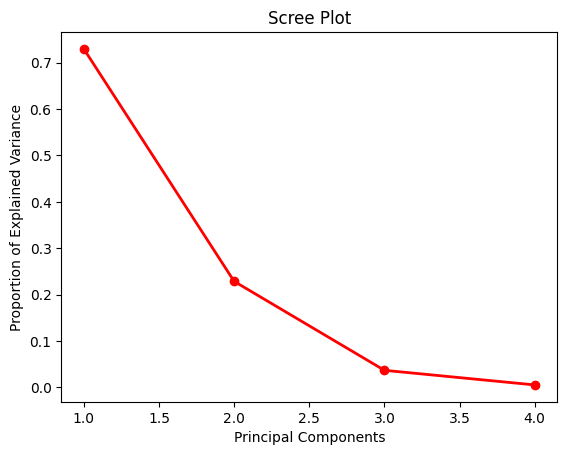

In [30]:
import matplotlib.pyplot as plt
#it has 4 components
#for graph +1 -- 1  2 3 4
PC_values = np.arange(pca.n_components_)+1
#every component's ratio
plt.plot(PC_values,pca.explained_variance_ratio_,'ro-',linewidth=2)
#r for red
#o for .
#-- for line
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Proportion of Explained Variance")
plt.show()

<BarContainer object of 4 artists>

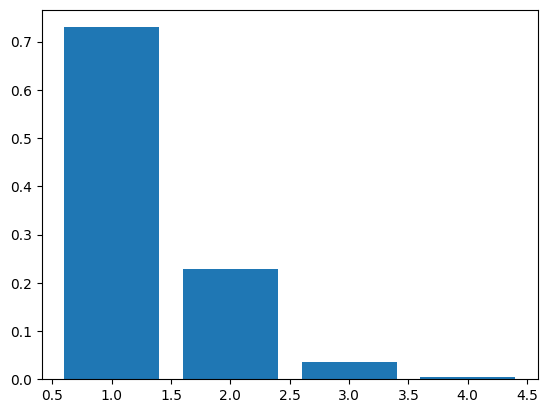

In [31]:
plt.bar(PC_values,pca.explained_variance_ratio_) #bar plot

In [33]:
loadings=pd.DataFrame(pca.components_.T, columns=['PC1','PC2','PC3','PC4'])
loadings

,PC1,PC2,PC3,PC4
0,0.521066,0.377418,0.719566,-0.261286
1,-0.269347,0.923296,-0.244382,0.123510
2,0.580413,0.024492,-0.142126,0.801449
3,0.564857,0.066942,-0.634273,-0.523597
